In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4" # only usee TITAN RTX

In [5]:
from PIL import Image
import torch
from diffusers import StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler

In [6]:
INPUT_FILE_NAME = "wwz.jpeg"
RAW_INPUT_IMG_PATH = os.path.join('./images/raw_input/', INPUT_FILE_NAME)
RESIZED_INPUT_DIR_PATH = os.path.join('./images/input/', INPUT_FILE_NAME)
OUTPUT_DIR_PATH = './images/output/'
MODEL_ID = "timbrooks/instruct-pix2pix"

In [21]:
def resize_image_keep_aspect(image, target_size=256):
    w, h = image.size

    if w == target_size or h == target_size: # do not resize if one dimension is already the target size
        print(f"Image already has one dimension of {target_size}, skipping resize.")
        return image
    
    if w > h:
        new_w = target_size
        new_h = int(h * (target_size / w))
    else:
        new_h = target_size
        new_w = int(w * (target_size / h))
    return image.resize((new_w, new_h))

def save_image(image, path):
    with open(path, 'wb') as f:
        image.save(f, format='PNG')

In [8]:
pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained(MODEL_ID, torch_dtype=torch.float16, safety_checker=None)
pipe.to("cuda")
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading pipeline components...: 100%|██████████| 6/6 [00:12<00:00,  2.08s/it]


# Image Manipulation

In [14]:
# Loading and resizing the image
if not os.path.exists(RESIZED_INPUT_DIR_PATH):
    print(f"Resizing image from {RAW_INPUT_IMG_PATH}.")
    image = Image.open(RAW_INPUT_IMG_PATH).convert("RGB")
    image_resized = resize_image_keep_aspect(image)
    save_image(image=image_resized, path=RESIZED_INPUT_DIR_PATH)
else:
    print(f"Using existing resized image at {RESIZED_INPUT_DIR_PATH}")
    image_resized = Image.open(RESIZED_INPUT_DIR_PATH).convert("RGB")

Using existing resized image at ./images/input/wwz.jpeg


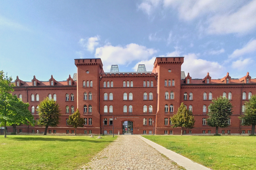

In [15]:
image_resized

In [16]:
prompt = "make the building look like a castle"

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:01<00:00, 17.41it/s]


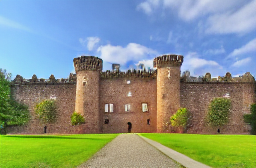

In [19]:
images = pipe(prompt, image=image_resized, num_inference_steps=20, image_guidance_scale=1).images
images[0]

In [22]:
save_image(image=images[0], path=os.path.join(OUTPUT_DIR_PATH, 'wwz_castle.png'))